# Learning EnKF localization with proper scoring rules

Localization is a technique often using in ensemble Kalman filters to maintain stability in high dimensions. In short, localization is necessary as the EnKF will build a $d_x \times d_y$ covariance matrix --- where $d_x$ is the dimension of the state $x_t$ and $d_y$ is the dimension of the observation $y_t$. This is done empirically through $N$ particles, which can be noisy if $N \ll d_x, d_y$. In physical systems, we can use _a priori_ knowledge about how dimensions of the state are related in order to cut down on spurious correlations.

To do this, we typically use the pairwise-distances and a positive-definite correlation function, e.g., from a Gaussian kernel. What remains, however, is the tuning of the lengthscale used by the correlation function. This loosely says at what distance we should expect diminishing _a priori_ correlations, and can be classically difficult to determine. 

In this tutorial, we show how the lengthscale can be learned with gradient-based optimization, using a Gaussian correlation function for localization and proper scoring rules to determine the optimum.

## Experimental design

We use a classical high-dimensional system where localization is necessary, the 40-dimensional Lorenz–96 system:

$$\frac{dx_i}{dt}=(x_{i+1}-x_{i-2})x_{i-1}-x_i+F,\qquad F=8,$$

with periodic indexing. We observe every other state with independent Gaussian noise. We use time indices 50–199 form the tuning window, and time indices 200–299 as a test set.

In [1]:
import os
from pathlib import Path

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist
from IPython.display import Markdown, display
from jaxopt import LBFGSB

import dynestyx as dsx
from dynestyx import DynamicalModel, Evaluation, Filter, LinearGaussianObservation
from dynestyx.evaluation.configs import ObservationScoringConfig
from dynestyx.evaluation.scoring import (
    DawidSebastianiScore,
    EnergyScore,
    GaussianLogProbScore,
    ObservationWiseCRPSScore,
)
from dynestyx.inference.configs.discretizer import ODEFlowConfig
from dynestyx.inference.filters import EnKFConfig, EnKFLocalizationConfig

STATE_DIM = 40
OBS_INDICES = jnp.arange(0, STATE_DIM, 2)
OBS_DIM = len(OBS_INDICES)
FORCING = 8.0
MODEL_DT = 0.01
STEPS_PER_CYCLE = 5
SPINUP_TIME = 10.0
N_CYCLES = 300
TUNE_START, TUNE_STOP = 50, 200
HOLDOUT_START, HOLDOUT_STOP = 200, 300
N_ENSEMBLE = 20
OBS_NOISE_STD = 1.0
INFLATION_DELTA = 0.05

STYLE_COLORS = {
    "warm_red": "#E64B35",
    "teal_green": "#009E73",
    "cyan_blue": "#56B4E9",
    "purple": "#8C79B8",
    "neutral_gray": "#5F5F5F",
    "light_gray": "#BDBDBD",
    "black": "#222222",
}
UNLOCALIZED_COLOR = STYLE_COLORS["warm_red"]
LOCALIZED_COLOR = STYLE_COLORS["teal_green"]
TRUTH_COLOR = STYLE_COLORS["black"]

mpl.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.9,
    "lines.linewidth": 2.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.frameon": False,
})

default_figure_dir = (
    Path("docs/deep_dives/figures/l96_localization_hyperparameter_scoring")
    if Path("docs").exists()
    else Path("figures/l96_localization_hyperparameter_scoring")
)
FIGURE_DIR = Path(os.environ.get("DYNESTYX_FIGURE_DIR", default_figure_dir))
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem):
    fig.savefig(FIGURE_DIR / f"{stem}.pdf")
    fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=300)


def despine_curve_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")


def box_image_axis(ax):
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(0.9)
    ax.tick_params(direction="out")


## Generate a deterministic Lorenz–96 twin experiment

We use `dsx.simulate` to integrate a continuous-time Lorenz–96 model and sample its noisy observations. We let the model spin-up for 10 time units, then use the remaining time units for a training set (to select the localization lengthscale) and a test set (to see how different lengthscales would have performed). We assume the model is known, and deploy an EnKF filter using a `Discretizer` with `ODEFlowConfig`. The filter uses the same settings as the solver, but with an uncertain Gaussian initial condition.

In [2]:
def l96_drift(x, u, t):
    return (jnp.roll(x, -1) - jnp.roll(x, 2)) * jnp.roll(x, 1) - x + FORCING


H = jnp.eye(STATE_DIM)[OBS_INDICES]
R = OBS_NOISE_STD**2 * jnp.eye(OBS_DIM)
ode_config = dsx.ODESimulatorConfig(dt0=MODEL_DT)


def l96_dynamics(initial_condition):
    return DynamicalModel(
        initial_condition=initial_condition,
        state_evolution=dsx.ContinuousTimeStateEvolution(drift=l96_drift),
        observation_model=LinearGaussianObservation(H=H, R=R),
    )


initial_truth = FORCING * jnp.ones(STATE_DIM)
initial_truth = initial_truth.at[0].add(0.01)
spinup = dsx.simulate(
    l96_dynamics(dist.Delta(initial_truth, event_dim=1)),
    rng_key=jr.PRNGKey(0),
    predict_times=jnp.array([0.0, SPINUP_TIME]),
    simulator_config=ode_config,
)
spun_up_truth = spinup.states[0, -1]

obs_times = MODEL_DT * STEPS_PER_CYCLE * jnp.arange(N_CYCLES)
truth = dsx.simulate(
    l96_dynamics(dist.Delta(spun_up_truth, event_dim=1)),
    rng_key=jr.PRNGKey(2026),
    predict_times=obs_times,
    simulator_config=ode_config,
)
# dsx.simulate retains a simulation axis even for a single trajectory.
truth_states = truth.states[0]
obs_values = truth.observations[0]
prior_mean = truth_states[0] + 1.5 * jr.normal(jr.PRNGKey(9), (STATE_DIM,))

print("truth states:", truth_states.shape)
print("observations:", obs_values.shape)
print(f"tuning cycles: {TUNE_START}:{TUNE_STOP}")
print(f"held-out cycles: {HOLDOUT_START}:{HOLDOUT_STOP}")


truth states: (300, 40)
observations: (300, 20)
tuning cycles: 50:200
held-out cycles: 200:300


In [3]:
filter_dynamics = l96_dynamics(
    dist.MultivariateNormal(
        loc=prior_mean, covariance_matrix=2.0**2 * jnp.eye(STATE_DIM)
    )
)
discretizer_config = ODEFlowConfig(simulator_config=ode_config)


## A positive-definite Gaussian taper on the periodic domain

In order to use a taper, we must define pairwise distances. The Lorenz-96 sites live on a ring domain; to make sure that correlation functions remain positive-definite, we embed this ring in Euclidean space, then use the Euclidean distance. Note that this is not the typical distance function used, which is usually the difference in indices; however, this produces non-PSD covariance matrices when using the Gaussian taper instead of the more common Gaspari-Cohn taper. We use the former as it has better gradient properties.

The callable passed as `taper` receives a complete distance matrix. Its closure holds the candidate length scale; because the scale lives in the closure, `taper_scale` remains `None`.

In [4]:
angles = 2.0 * jnp.pi * jnp.arange(STATE_DIM) / STATE_DIM
ring_radius = STATE_DIM / (2.0 * jnp.pi)
state_coordinates = ring_radius * jnp.stack(
    [jnp.cos(angles), jnp.sin(angles)], axis=-1
)
observation_coordinates = state_coordinates[OBS_INDICES]


def pairwise_distance(left, right):
    return jnp.linalg.norm(left[:, None, :] - right[None, :, :], axis=-1)


state_observation_distances = pairwise_distance(
    state_coordinates, observation_coordinates
)
observation_distances = pairwise_distance(
    observation_coordinates, observation_coordinates
)


def gaussian_covariance(length_scale):
    def covariance(distance):
        return jnp.exp(-0.5 * jnp.square(distance / length_scale))

    return covariance


def make_localization(length_scale):
    return EnKFLocalizationConfig(
        state_observation_distances=state_observation_distances,
        observation_distances=observation_distances,
        taper=gaussian_covariance(length_scale),
        taper_scale=None,
    )


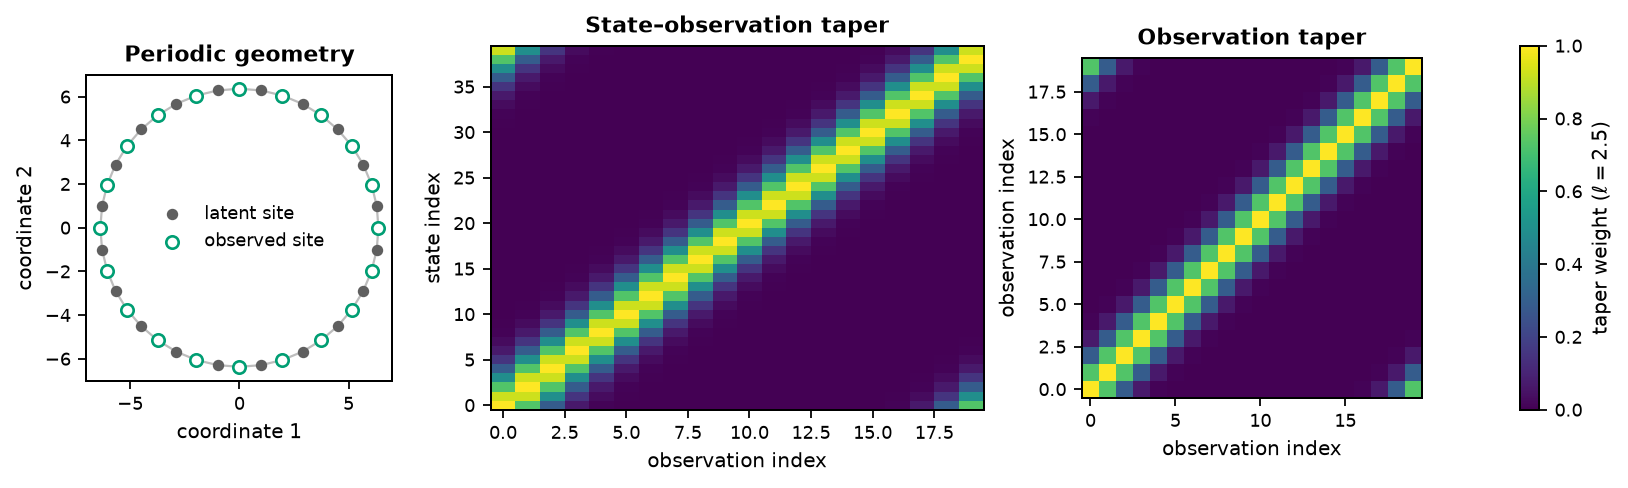

In [5]:
illustration_scale = 2.5
illustration_taper = gaussian_covariance(illustration_scale)
cross_taper = illustration_taper(state_observation_distances)
marginal_taper = illustration_taper(observation_distances)

fig = plt.figure(figsize=(10.2, 3.25))
grid = fig.add_gridspec(
    1, 4, width_ratios=(0.9, 1.45, 1.0, 0.055), wspace=0.34
)
ax_geometry = fig.add_subplot(grid[0])
ax_cross = fig.add_subplot(grid[1])
ax_marginal = fig.add_subplot(grid[2])
ax_colorbar = fig.add_subplot(grid[3])

ax_geometry.plot(
    np.r_[np.asarray(state_coordinates[:, 0]), float(state_coordinates[0, 0])],
    np.r_[np.asarray(state_coordinates[:, 1]), float(state_coordinates[0, 1])],
    color=STYLE_COLORS["light_gray"], linewidth=1.0, zorder=0,
)
ax_geometry.scatter(
    state_coordinates[:, 0], state_coordinates[:, 1], s=17,
    color=STYLE_COLORS["neutral_gray"], label="latent site", zorder=1,
)
ax_geometry.scatter(
    observation_coordinates[:, 0], observation_coordinates[:, 1], s=31,
    facecolors="white", edgecolors=LOCALIZED_COLOR, linewidths=1.2,
    label="observed site", zorder=2,
)
ax_geometry.set_aspect("equal")
ax_geometry.set_title("Periodic geometry", fontweight="bold")
ax_geometry.set_xlabel("coordinate 1")
ax_geometry.set_ylabel("coordinate 2")
ax_geometry.legend(loc="center", ncol=1)
box_image_axis(ax_geometry)

image_cross = ax_cross.imshow(
    cross_taper, aspect="auto", origin="lower", vmin=0.0, vmax=1.0, cmap="viridis"
)
ax_cross.set_title("State–observation taper", fontweight="bold")
ax_cross.set_xlabel("observation index")
ax_cross.set_ylabel("state index")
box_image_axis(ax_cross)

ax_marginal.imshow(
    marginal_taper, aspect="equal", origin="lower", vmin=0.0, vmax=1.0, cmap="viridis"
)
ax_marginal.set_title("Observation taper", fontweight="bold")
ax_marginal.set_xlabel("observation index")
ax_marginal.set_ylabel("observation index")
box_image_axis(ax_marginal)
colorbar = fig.colorbar(image_cross, cax=ax_colorbar)
colorbar.set_label(fr"taper weight ($\ell={illustration_scale}$)")
fig.subplots_adjust(left=0.07, right=0.96, bottom=0.18, top=0.88)
save_figure(fig, "circle_geometry_and_tapers")
plt.show()


## Score candidate localization scales

We evaluate each localization scale using four different proper scoring rules provided in dynestyx: multivariate Gaussian log probability, Dawid–Sebastiani score, componentwise Gaussian CRPS, and the multivariate energy score. Higher Gaussian log probability is better; the other three scores are losses and are better when lower. Every score below is averaged only over cycles 50–199. 

In [6]:
METRIC_SPECS = (
    ("gaussian_log_prob", "Gaussian log probability", "higher"),
    ("dawid_sebastiani", "Dawid–Sebastiani", "lower"),
    ("observation_wise_crps", "Observation-wise CRPS", "lower"),
    ("energy_score", "Gaussian-moment energy score", "lower"),
)

scoring_config = ObservationScoringConfig(
    rules=(
        GaussianLogProbScore(),
        DawidSebastianiScore(),
        ObservationWiseCRPSScore(),
        EnergyScore(beta=1.0, n_samples=64),
    ),
    sample_source="gaussian_moments",
    sample_seed=2718,
    record_as_numpyro_sites=False,
)

gaussian_scoring_config = ObservationScoringConfig(
    rules=(GaussianLogProbScore(),),
    record_as_numpyro_sites=False,
)


def make_enkf_config(length_scale, *, include_predictions=True):
    localization = None if length_scale is None else make_localization(length_scale)
    return EnKFConfig(
        n_particles=N_ENSEMBLE,
        crn_seed=jr.PRNGKey(31415),
        perturb_measurements=False,
        inflation_delta=INFLATION_DELTA,
        localization=localization,
        include_predicted_observations=include_predictions,
        record_filtered_states_mean=False,
        record_filtered_states_cov=False,
        record_filtered_states_cov_diag=False,
        record_filtered_states_chol_cov=False,
        record_filtered_particles=False,
        record_predicted_observations_mean=False,
        record_predicted_observations_cov=False,
        record_predicted_observations_ensemble=False,
        warn=False,
    )


def condition_with_scores(length_scale, *, stop, score_config=scoring_config):
    with Evaluation(observation_scoring_config=score_config):
        with Filter(filter_config=make_enkf_config(length_scale)):
            with dsx.Discretizer(discretizer_config):
                return dsx.condition(
                    "f",
                    filter_dynamics,
                    obs_times=obs_times[:stop],
                    obs_values=obs_values[:stop],
                )


def tuning_score_vector(length_scale):
    result = condition_with_scores(length_scale, stop=TUNE_STOP)
    scores = result.evaluation_result.observation_scores
    return jnp.stack([
        jnp.mean(scores[name][TUNE_START:TUNE_STOP])
        for name, _, _ in METRIC_SPECS
    ])


In [7]:
LENGTH_SCALE_GRID = jnp.linspace(0.5, 6.0, 24)
grid_scores = np.asarray(jax.vmap(tuning_score_vector)(LENGTH_SCALE_GRID))
length_scale_grid_np = np.asarray(LENGTH_SCALE_GRID)

grid_best_indices = []
profile_lines = [
    "| Scoring rule | Direction | Best grid scale | Mean tuning score |",
    "|---|:---:|---:|---:|",
]
for metric_index, (_, label, direction) in enumerate(METRIC_SPECS):
    values = grid_scores[:, metric_index]
    best_index = int(np.argmax(values) if direction == "higher" else np.argmin(values))
    grid_best_indices.append(best_index)
    profile_lines.append(
        f"| {label} | {direction} | {length_scale_grid_np[best_index]:.3f} | {values[best_index]:.5f} |"
    )

display(Markdown("\n".join(profile_lines)))
print("grid score array shape:", grid_scores.shape)


| Scoring rule | Direction | Best grid scale | Mean tuning score |
|---|:---:|---:|---:|
| Gaussian log probability | higher | 6.000 | -29.59992 |
| Dawid–Sebastiani | lower | 6.000 | 22.44229 |
| Observation-wise CRPS | lower | 5.761 | 0.60200 |
| Gaussian-moment energy score | lower | 6.000 | 3.38426 |

grid score array shape: (24, 4)


## Learning lengthscales with gradient-based optimization

We now show how, instead of constructing a whole grid, we can use gradient-based optimization to learn the optimal localization lengthscale. In this case, we use L-BGFS-B, as provided by `jaxopt`, constrained to the existing grid $0.5 \leq \ell \leq 6$. We derive the optimum using the Gaussian log score, though in principle this is also possilbe with the other scoring rules.

In [8]:
def tuning_gaussian_log_score(length_scale):
    result = condition_with_scores(
        length_scale, stop=TUNE_STOP, score_config=gaussian_scoring_config
    )
    return jnp.mean(
        result.evaluation_result.observation_scores["gaussian_log_prob"]
        [TUNE_START:TUNE_STOP]
    )


def optimization_objective(length_scale):
    return -tuning_gaussian_log_score(length_scale)


gaussian_grid_best_index = grid_best_indices[0]
initial_scale = LENGTH_SCALE_GRID[gaussian_grid_best_index]
initial_value, initial_gradient = jax.value_and_grad(optimization_objective)(
    initial_scale
)
solver = LBFGSB(
    fun=optimization_objective,
    maxiter=20,
    tol=1e-5,
    history_size=8,
    implicit_diff=False,
)
optimization_result = solver.run(
    initial_scale, bounds=(jnp.array(0.5), jnp.array(6.0))
)
optimized_scale = float(optimization_result.params)
optimized_log_score = -float(optimization_result.state.value)

print(f"grid starting scale : {float(initial_scale):.5f}")
print(f"initial gradient    : {float(initial_gradient): .6f}")
print(f"L-BFGS-B scale      : {optimized_scale:.5f}")
print(f"mean tuning log score: {optimized_log_score:.6f}")
print(f"iterations          : {int(optimization_result.state.iter_num)}")
print(f"final error         : {float(optimization_result.state.error):.3e}")


grid starting scale : 6.00000
initial gradient    : -0.008263
L-BFGS-B scale      : 6.00000
mean tuning log score: -29.599915
iterations          : 1
final error         : 0.000e+00


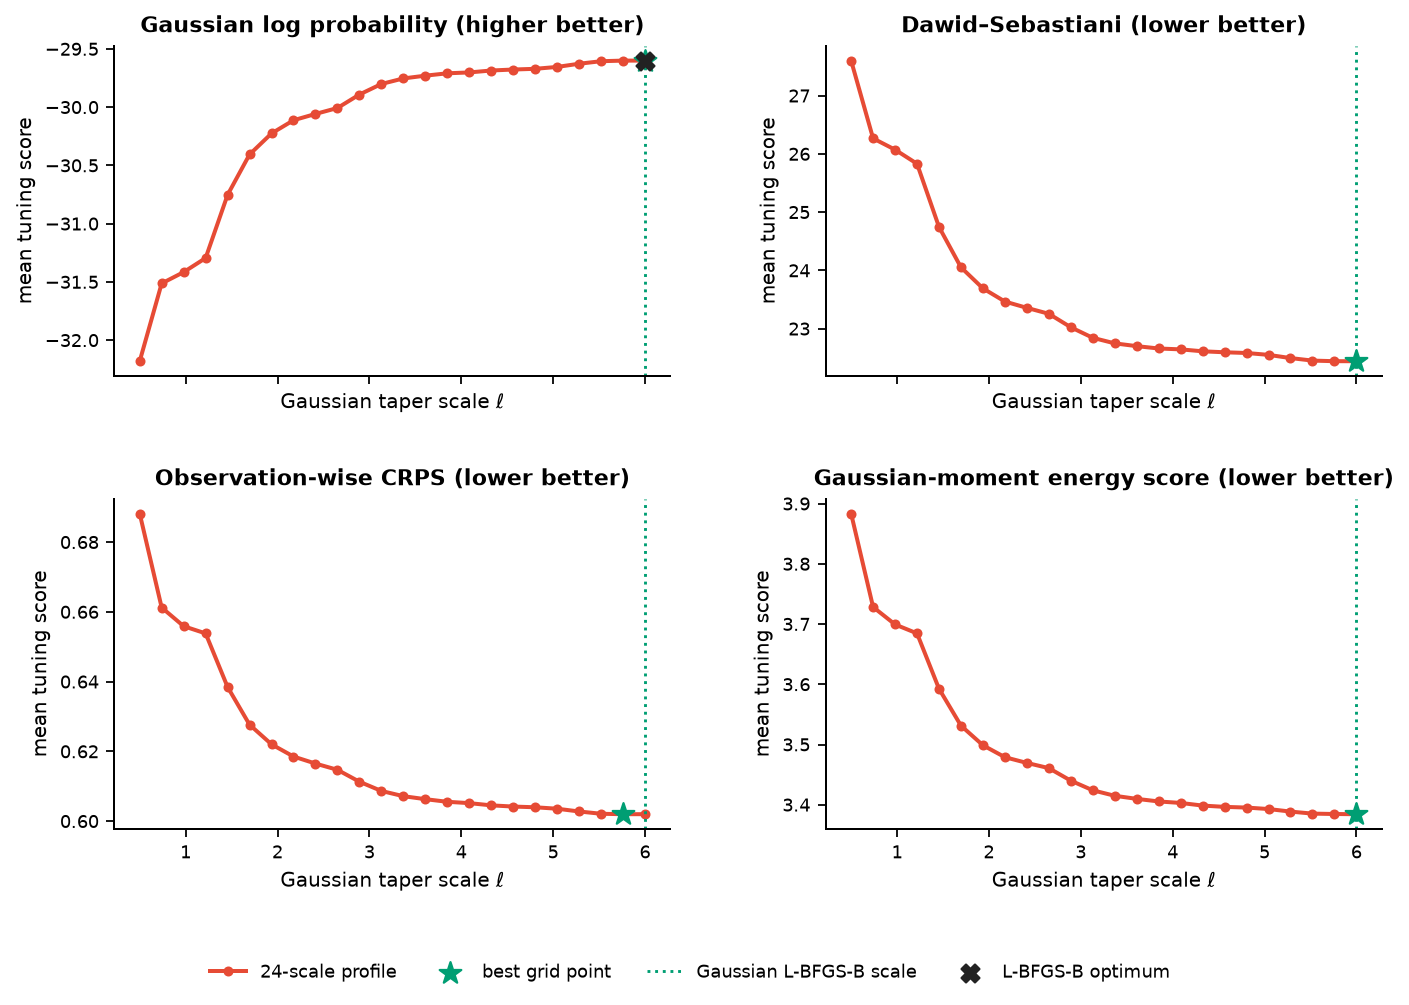

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(9.0, 6.2), sharex=True)
for metric_index, (ax, (_, label, direction)) in enumerate(
    zip(axes.ravel(), METRIC_SPECS, strict=True)
):
    values = grid_scores[:, metric_index]
    best_index = grid_best_indices[metric_index]
    ax.plot(
        length_scale_grid_np, values, color=UNLOCALIZED_COLOR, marker="o",
        markersize=3.5, linewidth=1.8, label="24-scale profile",
    )
    ax.scatter(
        length_scale_grid_np[best_index], values[best_index],
        marker="*", s=105, color=LOCALIZED_COLOR, zorder=3, label="best grid point",
    )
    ax.axvline(
        optimized_scale, color=LOCALIZED_COLOR, linestyle=":", linewidth=1.3,
        label="Gaussian L-BFGS-B scale",
    )
    if metric_index == 0:
        ax.scatter(
            optimized_scale, optimized_log_score, marker="X", s=65,
            color=STYLE_COLORS["black"], zorder=4, label="L-BFGS-B optimum",
        )
    ax.set_title(f"{label} ({direction} better)", fontweight="bold")
    ax.set_xlabel(r"Gaussian taper scale $\ell$")
    ax.set_ylabel("mean tuning score")
    despine_curve_axis(ax)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.01), ncol=4)
fig.subplots_adjust(left=0.10, right=0.98, bottom=0.16, top=0.95, hspace=0.37, wspace=0.28)
save_figure(fig, "localization_score_profiles")
plt.show()


## Held-out comparison with no localization

Now, let's see how we did on the test set! Remember, we only used the first 200 steps as training data; we will now compare localized and unlocalized filters on the final 100 steps of observations. We report all four predictive scores along with state RMSE and the spread–error ratio

$$\frac{\sqrt{\operatorname{mean}_{t,i}\operatorname{Var}_n(x_{t,i}^{(n)})}}{\sqrt{\operatorname{mean}_{t,i}(\bar x_{t,i}-x_{t,i}^{\mathrm{true}})^2}}.$$

A ratio near one is a useful calibration diagnostic, though not sufficient for good tracking and prediction.

In [10]:
def full_filter_diagnostics(length_scale):
    result = condition_with_scores(length_scale, stop=N_CYCLES)
    ensemble = np.asarray(result.states.ensemble)
    mean = ensemble.mean(axis=1)
    variance = ensemble.var(axis=1, ddof=1)
    score_arrays = result.evaluation_result.observation_scores
    heldout_scores = {
        name: float(jnp.mean(score_arrays[name][HOLDOUT_START:HOLDOUT_STOP]))
        for name, _, _ in METRIC_SPECS
    }
    error = mean[HOLDOUT_START:HOLDOUT_STOP] - np.asarray(
        truth_states[HOLDOUT_START:HOLDOUT_STOP]
    )
    rmse = float(np.sqrt(np.mean(error**2)))
    rms_spread = float(
        np.sqrt(np.mean(variance[HOLDOUT_START:HOLDOUT_STOP]))
    )
    return {
        "ensemble": ensemble,
        "mean": mean,
        "variance": variance,
        "scores": heldout_scores,
        "rmse": rmse,
        "rms_spread": rms_spread,
        "spread_error_ratio": rms_spread / rmse,
    }


diagnostics = {
    "Unlocalized": full_filter_diagnostics(None),
    fr"Localized ($\ell={optimized_scale:.3f}$)": full_filter_diagnostics(optimized_scale),
}


In [11]:
summary_lines = [
    "| Method | Gaussian log prob ↑ | DSS ↓ | CRPS ↓ | Energy ↓ | State RMSE ↓ | Spread/error |",
    "|---|---:|---:|---:|---:|---:|---:|",
]
for method, result in diagnostics.items():
    score = result["scores"]
    summary_lines.append(
        f"| {method} | {score['gaussian_log_prob']:.4f} | {score['dawid_sebastiani']:.4f} | "
        f"{score['observation_wise_crps']:.4f} | {score['energy_score']:.4f} | "
        f"{result['rmse']:.4f} | {result['spread_error_ratio']:.3f} |"
    )
display(Markdown("\n".join(summary_lines)))


| Method | Gaussian log prob ↑ | DSS ↓ | CRPS ↓ | Energy ↓ | State RMSE ↓ | Spread/error |
|---|---:|---:|---:|---:|---:|---:|
| Unlocalized | -133.1286 | 229.4996 | 2.1946 | 12.7810 | 3.5820 | 0.075 |
| Localized ($\ell=6.000$) | -29.2532 | 21.7489 | 0.5899 | 3.3140 | 0.2568 | 1.042 |

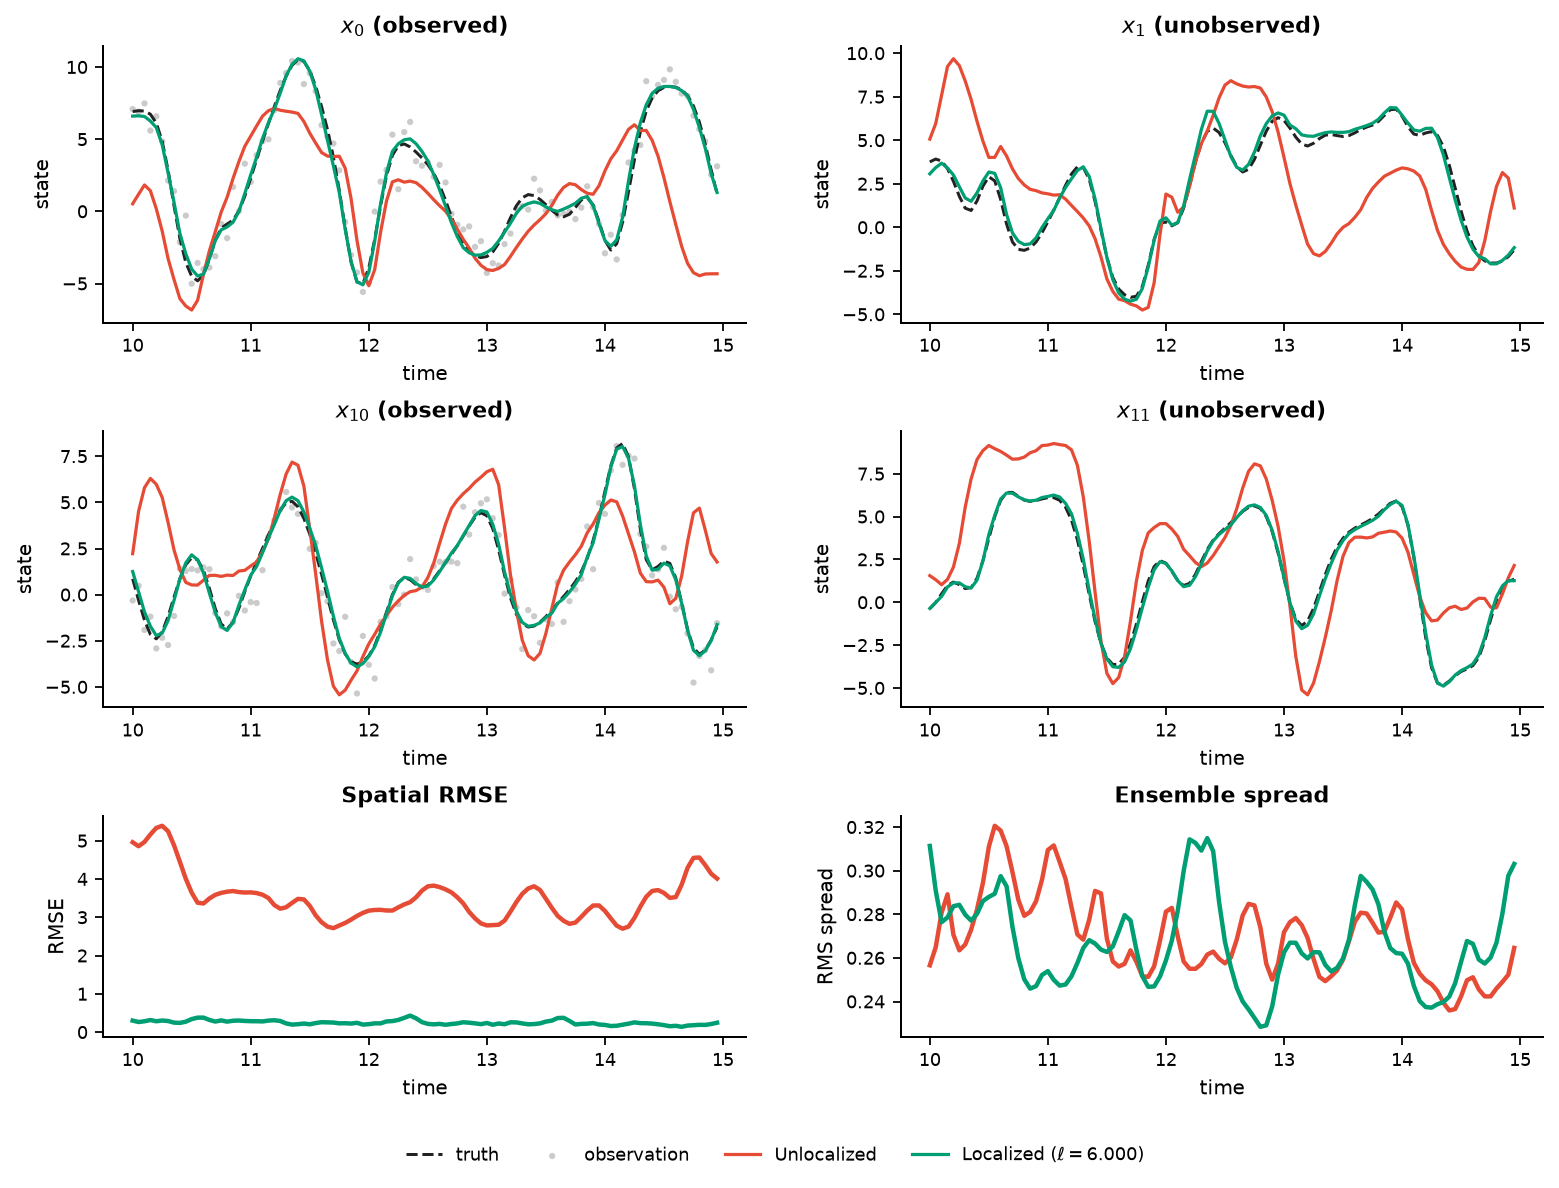

In [12]:
method_colors = {
    "Unlocalized": UNLOCALIZED_COLOR,
    next(name for name in diagnostics if name.startswith("Localized")): LOCALIZED_COLOR,
}
holdout_slice = slice(HOLDOUT_START, HOLDOUT_STOP)
holdout_times = np.asarray(obs_times[holdout_slice])
truth_np = np.asarray(truth_states)
observations_np = np.asarray(obs_values)
representative_states = (0, 1, 10, 11)

fig = plt.figure(figsize=(10.0, 7.2))
grid = fig.add_gridspec(3, 2, height_ratios=(1.0, 1.0, 0.8), hspace=0.42, wspace=0.24)
trajectory_axes = [fig.add_subplot(grid[row, column]) for row in range(2) for column in range(2)]
ax_rmse = fig.add_subplot(grid[2, 0])
ax_spread = fig.add_subplot(grid[2, 1])

for ax, state_index in zip(trajectory_axes, representative_states, strict=True):
    ax.plot(
        holdout_times, truth_np[holdout_slice, state_index],
        color=TRUTH_COLOR, linestyle="--", linewidth=1.35, label="truth",
    )
    is_observed = state_index % 2 == 0
    if is_observed:
        obs_column = state_index // 2
        ax.scatter(
            holdout_times, observations_np[holdout_slice, obs_column],
            s=8, color=STYLE_COLORS["neutral_gray"], alpha=0.32,
            edgecolors="none", label="observation",
        )
    for method, result in diagnostics.items():
        ax.plot(
            holdout_times, result["mean"][holdout_slice, state_index],
            color=method_colors[method], linewidth=1.45, label=method,
        )
    site_type = "observed" if is_observed else "unobserved"
    ax.set_title(fr"$x_{{{state_index}}}$ ({site_type})", fontweight="bold")
    ax.set_xlabel("time")
    ax.set_ylabel("state")
    despine_curve_axis(ax)

for method, result in diagnostics.items():
    error = result["mean"][holdout_slice] - truth_np[holdout_slice]
    rmse_by_time = np.sqrt(np.mean(error**2, axis=-1))
    spread_by_time = np.sqrt(np.mean(result["variance"][holdout_slice], axis=-1))
    ax_rmse.plot(holdout_times, rmse_by_time, color=method_colors[method], label=method)
    ax_spread.plot(holdout_times, spread_by_time, color=method_colors[method], label=method)

ax_rmse.set_title("Spatial RMSE", fontweight="bold")
ax_rmse.set_xlabel("time")
ax_rmse.set_ylabel("RMSE")
ax_spread.set_title("Ensemble spread", fontweight="bold")
ax_spread.set_xlabel("time")
ax_spread.set_ylabel("RMS spread")
despine_curve_axis(ax_rmse)
despine_curve_axis(ax_spread)

handles, labels = trajectory_axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.015), ncol=4)
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.11, top=0.97)
save_figure(fig, "optimized_vs_unlocalized_diagnostics")
plt.show()
